# MLOps Capstone — Notebook 3: Hotel Recommendation System
## Collaborative Filtering with SVD

**Project Summary:**  
This notebook builds a hotel recommendation system using **collaborative filtering** — predicting which hotels a user would prefer based on the behaviour of similar users. The model uses **Truncated SVD (Singular Value Decomposition)** to decompose the user-hotel interaction matrix into latent factors, then reconstructs predicted ratings for unvisited hotels.

**GitHub Repository:** `https://github.com/<your-username>/mlops-travel-capstone`

---
| Section | Content |
|---------|--------|
| 0 | Install & Import |
| 1 | Load Datasets |
| 2 | EDA — Hotels & Users |
| 3 | Build User-Hotel Interaction Matrix |
| 4 | SVD Collaborative Filtering Model |
| 5 | Hyperparameter Tuning (n_components) |
| 6 | MLflow Tracking |
| 7 | Evaluation (Coverage · Diversity · Precision@K) |
| 8 | Recommendation Function |
| 9 | Save Model & Artefacts |
| 10 | MLflow Run Summary |

## 0. Install & Import Libraries

In [1]:
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn joblib scipy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.model_selection import KFold
import mlflow
import mlflow.sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded. MLflow version:', mlflow.__version__)

Libraries loaded. MLflow version: 3.12.0


## 1. Load Datasets

In [3]:
hotels = pd.read_csv(r"C:\Users\shourya\Desktop\travel-mlops-project\hotel_recommendation\data\hotels.csv")
users = pd.read_csv(r"C:\Users\shourya\Desktop\travel-mlops-project\hotel_recommendation\data\users.csv")
print('hotels shape:', hotels.shape)
print('users  shape:', users.shape)
print('\nHotels columns:', list(hotels.columns))
display(hotels.head())
print('\nMissing values — hotels:', hotels.isnull().sum().sum())
print('Missing values — users :', users.isnull().sum().sum())

hotels shape: (40552, 8)
users  shape: (1340, 5)

Hotels columns: ['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019



Missing values — hotels: 0
Missing values — users : 0


## 2. EDA — Hotels & Users

Understanding the distribution of hotel visits, spend patterns, and stay durations is essential before building a recommendation system. We also check sparsity of the user-hotel interaction matrix — a key property that determines which algorithm to use.

In [4]:
print('=== Hotel Stats ===')
print(hotels.describe())
print('\nHotel visit counts:')
print(hotels['name'].value_counts())
print('\nHotel places:')
print(hotels['place'].value_counts())

=== Hotel Stats ===
          travelCode      userCode          days         price         total
count   40552.000000  40552.000000  40552.000000  40552.000000  40552.000000
mean    67911.794461    666.963726      2.499679    214.439554    536.229513
std     39408.199333    391.136794      1.119326     76.742305    319.331482
min         0.000000      0.000000      1.000000     60.390000     60.390000
25%     33696.750000    323.000000      1.000000    165.990000    247.620000
50%     67831.000000    658.000000      2.000000    242.880000    495.240000
75%    102211.250000   1013.000000      4.000000    263.410000    742.860000
max    135942.000000   1339.000000      4.000000    313.020000   1252.080000

Hotel visit counts:
name
Hotel K     5094
Hotel CB    5029
Hotel BD    4829
Hotel AF    4828
Hotel AU    4467
Hotel BP    4437
Hotel BW    4333
Hotel Z     4205
Hotel A     3330
Name: count, dtype: int64

Hotel places:
place
Salvador (BH)          5094
Rio de Janeiro (RJ)    5029
Natal

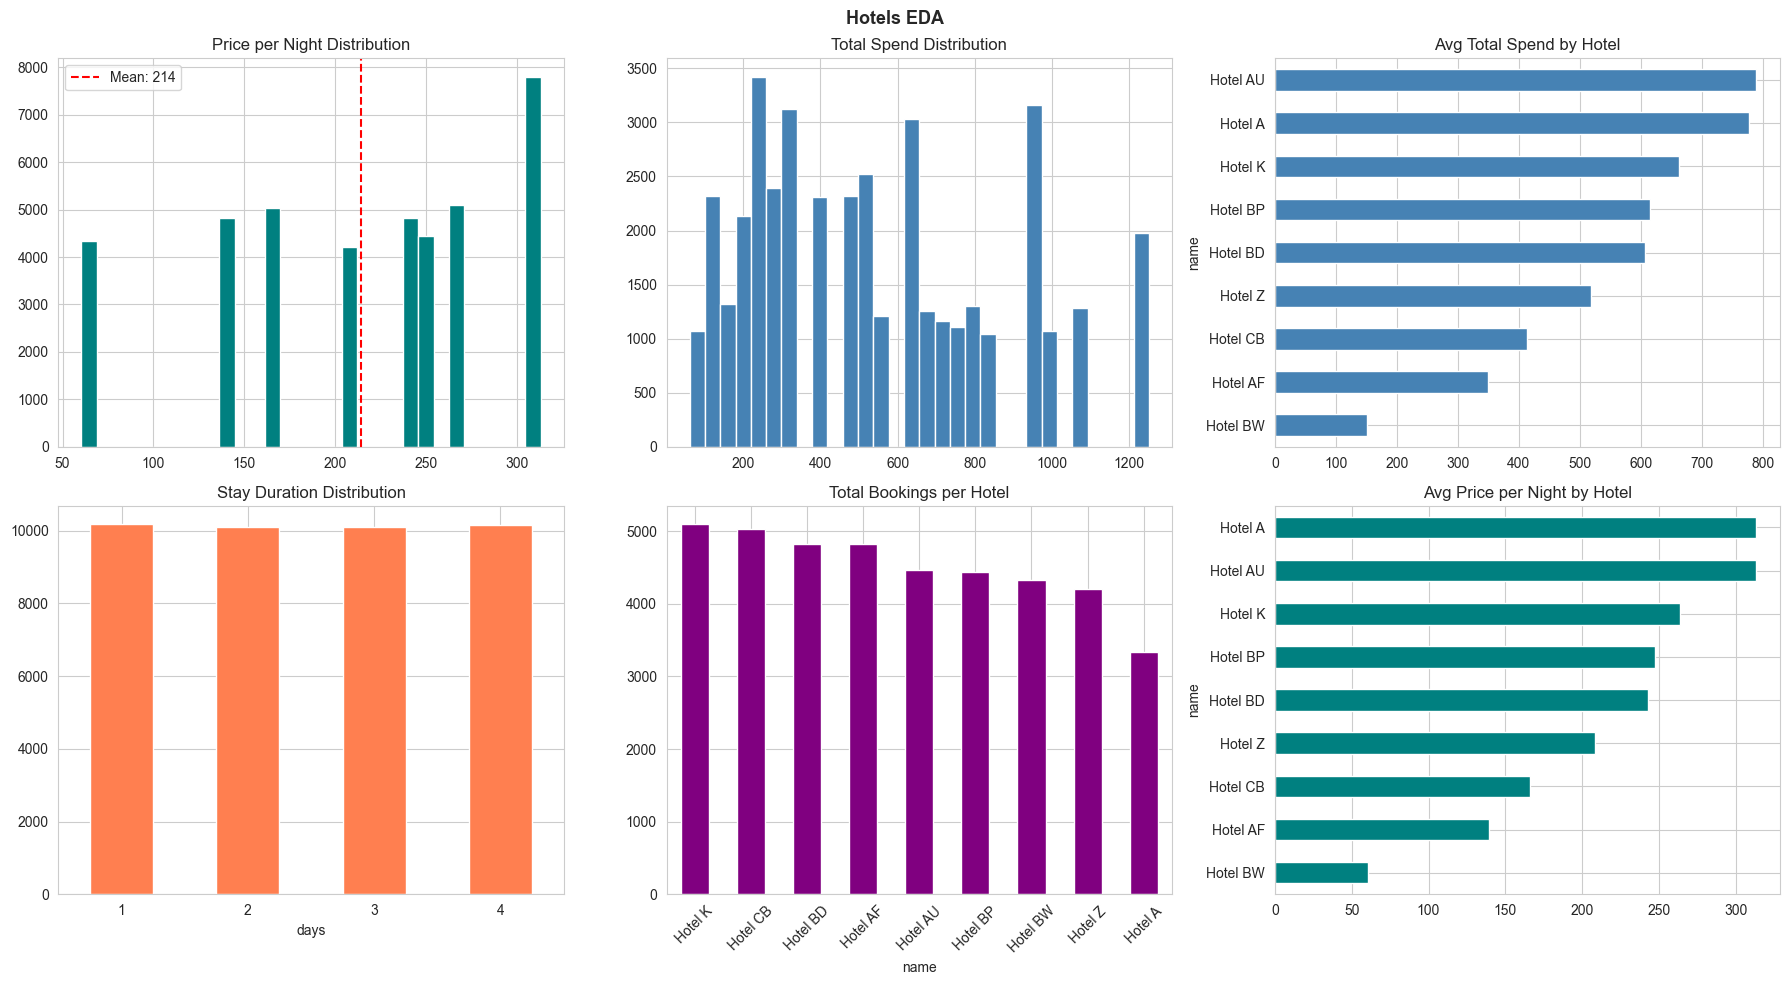

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hotels EDA', fontsize=13, fontweight='bold')

# Price per night
axes[0,0].hist(hotels['price'], bins=30, color='teal', edgecolor='white')
axes[0,0].axvline(hotels['price'].mean(), color='red', linestyle='--', label=f'Mean: {hotels["price"].mean():.0f}')
axes[0,0].set_title('Price per Night Distribution'); axes[0,0].legend()

# Total spend
axes[0,1].hist(hotels['total'], bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('Total Spend Distribution')

# Avg total spend by hotel
hotels.groupby('name')['total'].mean().sort_values().plot(kind='barh', ax=axes[0,2], color='steelblue', edgecolor='white')
axes[0,2].set_title('Avg Total Spend by Hotel')

# Days distribution
hotels['days'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Stay Duration Distribution'); axes[1,0].tick_params(axis='x', rotation=0)

# Bookings per hotel
hotels['name'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple', edgecolor='white')
axes[1,1].set_title('Total Bookings per Hotel'); axes[1,1].tick_params(axis='x', rotation=45)

# Price by hotel
hotels.groupby('name')['price'].mean().sort_values().plot(kind='barh', ax=axes[1,2], color='teal', edgecolor='white')
axes[1,2].set_title('Avg Price per Night by Hotel')

plt.tight_layout()
plt.savefig('nb3_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Hotels visited per user
hotels_per_user = hotels.groupby('userCode')['name'].nunique()
print('Hotels visited per user:')
print(hotels_per_user.value_counts().sort_index())
print(f'\nUsers who visited all 9 hotels: {(hotels_per_user == 9).sum()}')
print(f'Users who visited < 5 hotels  : {(hotels_per_user < 5).sum()}')
print(f'\nUnique users in hotels dataset: {hotels["userCode"].nunique()}')
print(f'Users in users.csv            : {len(users)}')

Hotels visited per user:
name
1     25
2     28
3     33
4     43
5     58
6     76
7    126
8    545
9    376
Name: count, dtype: int64

Users who visited all 9 hotels: 376
Users who visited < 5 hotels  : 129

Unique users in hotels dataset: 1310
Users in users.csv            : 1340


## 3. Build User-Hotel Interaction Matrix

Collaborative filtering requires a **user × item matrix** where each cell represents how strongly a user has interacted with an item. We use **total spend** as the implicit rating signal — a user who spent more at a hotel implicitly preferred it over others.

- Rows: user codes
- Columns: hotel names (9 hotels)
- Values: total spend (0 = not visited)

In [7]:
# Sum total spend per user per hotel
hotel_raw = hotels.groupby(['userCode','name'])['total'].sum().reset_index()
hotel_raw.columns = ['userCode','hotel','implicit_rating']

# Pivot to user × hotel matrix
INTERACTION_MATRIX = hotel_raw.pivot_table(
    index='userCode', columns='hotel', values='implicit_rating', fill_value=0)

print('Interaction matrix shape:', INTERACTION_MATRIX.shape)
print('Hotels:', list(INTERACTION_MATRIX.columns))
sparsity = (INTERACTION_MATRIX == 0).sum().sum() / INTERACTION_MATRIX.size * 100
print(f'Sparsity: {sparsity:.1f}% zeros')
display(INTERACTION_MATRIX.head())

Interaction matrix shape: (1310, 9)
Hotels: ['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K', 'Hotel Z']
Sparsity: 17.5% zeros


hotel,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,2191.14,1530.1,1564.15,2185.92,990.48,301.95,165.99,5004.79,2080.40
1,0.00,139.1,0.00,0.00,247.62,0.00,0.00,0.00,0.00
2,5634.36,834.6,1876.98,1700.16,1238.10,1207.80,1161.93,2897.51,3536.68
3,6886.44,1808.3,5630.94,6072.00,1238.10,1328.58,2489.85,3687.74,832.16
4,5634.36,2364.7,6569.43,3886.08,2228.58,724.68,4481.73,3687.74,2080.40


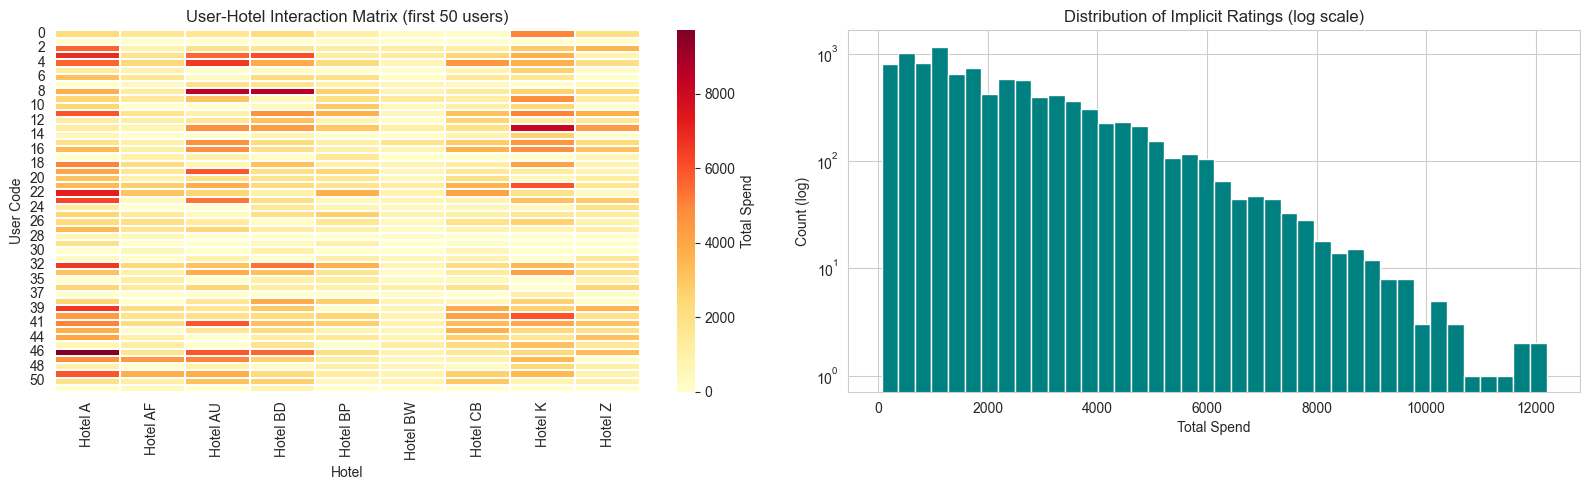

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of first 50 users
sample_matrix = INTERACTION_MATRIX.head(50)
sns.heatmap(sample_matrix, cmap='YlOrRd', ax=axes[0], linewidths=0.1,
            cbar_kws={'label': 'Total Spend'})
axes[0].set_title('User-Hotel Interaction Matrix (first 50 users)')
axes[0].set_xlabel('Hotel'); axes[0].set_ylabel('User Code')

# Distribution of implicit ratings
ratings_flat = hotel_raw['implicit_rating']
axes[1].hist(ratings_flat, bins=40, color='teal', edgecolor='white', log=True)
axes[1].set_title('Distribution of Implicit Ratings (log scale)')
axes[1].set_xlabel('Total Spend'); axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('nb3_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Why collaborative filtering over content-based filtering?

Content-based filtering recommends hotels similar to what a user has visited before (based on hotel features like price, location). Collaborative filtering recommends hotels based on what *similar users* preferred — capturing patterns content-based filtering misses (e.g., users with similar spending profiles tend to prefer the same hotels even across different locations).

With 1,310 users × 9 hotels, we have enough user overlap to find meaningful similarities. Content-based would need rich hotel feature data (amenities, ratings, categories) which this dataset doesn't provide.

### Why SVD over direct cosine similarity?

Direct cosine similarity on the raw matrix compares users based on their exact spend amounts. SVD first decomposes the matrix into latent factors (hidden preference dimensions) and then computes similarity in that lower-dimensional space — filtering out noise and making the similarity measure more robust.

### Why total spend as implicit rating instead of booking count?

Booking count treats a 1-night budget stay the same as a 10-night luxury stay. Total spend better captures the *strength* of preference — a user who spent ₹5,000 at Hotel AU clearly has a stronger preference for it than one who spent ₹150.

## 4. SVD Collaborative Filtering Model

**Why SVD?**  
With only 9 hotels, the interaction matrix is small but dense. Truncated SVD decomposes it into latent factors that capture hidden patterns — e.g., users who prefer budget hotels, users who prefer long stays, etc. — without needing explicit feature engineering.

**How it works:**  
`Matrix (users × hotels)` → SVD → `User factors` × `Singular values` × `Hotel factors ᵀ`  
Reconstructing the full matrix from these factors fills in predicted scores for unvisited hotels.

**Recommendation logic:**  
For a given user → identify unvisited hotels → rank by predicted score from reconstructed matrix → return top-N.

In [9]:
# Normalise rows so users with very high total spend don't dominate
matrix_norm = normalize(INTERACTION_MATRIX.values, norm='l2')

# Fit SVD with n_components=5 (tuned below)
N_COMPONENTS = 5
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
USER_FACTORS  = svd.fit_transform(matrix_norm)
ITEM_FACTORS  = svd.components_   # shape: (n_components, n_hotels)

print(f'SVD n_components: {N_COMPONENTS}')
print(f'Explained variance ratio: {svd.explained_variance_ratio_}')
print(f'Total variance explained: {svd.explained_variance_ratio_.sum():.3f}')

# Reconstruct predicted rating matrix
RECONSTRUCTED = np.dot(USER_FACTORS, ITEM_FACTORS)
RECON_DF = pd.DataFrame(RECONSTRUCTED, index=INTERACTION_MATRIX.index,
                         columns=INTERACTION_MATRIX.columns)
print('\nReconstructed matrix shape:', RECON_DF.shape)
display(RECON_DF.head())

SVD n_components: 5
Explained variance ratio: [0.05716896 0.22893583 0.17060001 0.15094327 0.1284476 ]
Total variance explained: 0.736

Reconstructed matrix shape: (1310, 9)


hotel,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,0.301155,0.197861,0.232024,0.311251,0.159916,0.084038,0.246996,0.723196,0.178353
1,0.016010,0.117640,-0.032166,-0.009668,0.831334,0.043208,0.113469,0.013827,0.247277
2,0.672980,0.161351,0.275168,0.266542,0.230187,0.066491,0.224743,0.360980,0.148247
3,0.583058,0.187618,0.442977,0.459020,0.058502,0.073028,0.254308,0.295623,0.183764
4,0.489788,0.191646,0.563242,0.347698,0.191627,0.074224,0.257983,0.327778,0.225278


## 5. Hyperparameter Tuning — n_components

The key hyperparameter for SVD is `n_components` — the number of latent factors. Too few: underfits (misses patterns). Too many: overfits (memorises exact interactions instead of generalising).

We evaluate each value of `n_components` using **reconstruction error** (how well the reduced matrix approximates the original) as the selection criterion.

SVD Hyperparameter Search:


,n_components,Reconstruction RMSE,Explained Variance
0,2,0.16526,0.2861
1,3,0.14417,0.4567
2,4,0.12252,0.6076
3,5,0.10050,0.7361
4,6,0.08076,0.8296
5,7,0.05805,0.9120
6,8,0.03225,0.9729


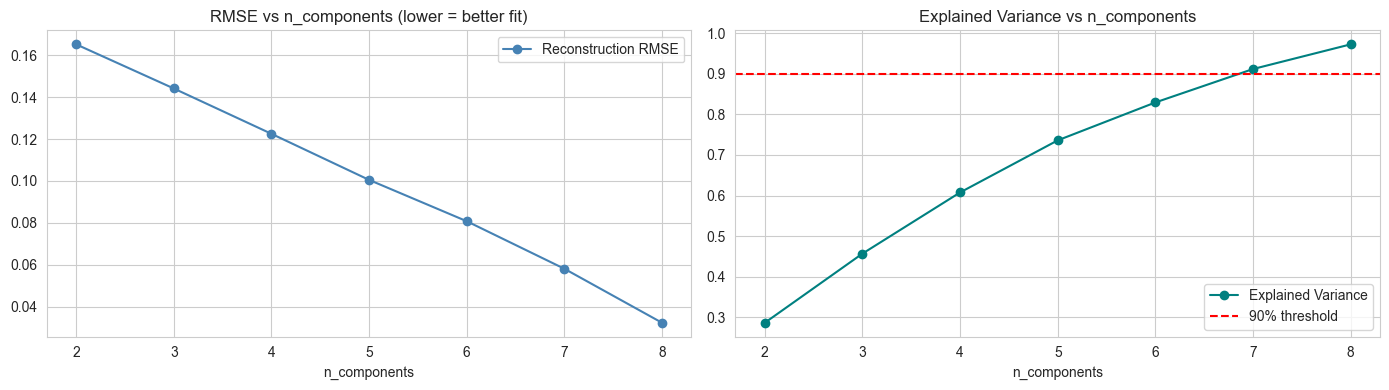


Selected n_components: 7 (first to exceed 85% explained variance)


In [10]:
from sklearn.metrics import mean_squared_error

components_range = [2, 3, 4, 5, 6, 7, 8]
results_svd = []

for n in components_range:
    svd_tmp = TruncatedSVD(n_components=n, random_state=RANDOM_STATE)
    U = svd_tmp.fit_transform(matrix_norm)
    recon = np.dot(U, svd_tmp.components_)
    rmse = np.sqrt(mean_squared_error(matrix_norm, recon))
    var  = svd_tmp.explained_variance_ratio_.sum()
    results_svd.append({'n_components': n, 'Reconstruction RMSE': round(rmse,5), 'Explained Variance': round(var,4)})

results_df_svd = pd.DataFrame(results_svd)
print('SVD Hyperparameter Search:')
display(results_df_svd)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
results_df_svd.plot(x='n_components', y='Reconstruction RMSE', ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('RMSE vs n_components (lower = better fit)')
results_df_svd.plot(x='n_components', y='Explained Variance', ax=axes[1], marker='o', color='teal')
axes[1].set_title('Explained Variance vs n_components')
axes[1].axhline(0.9, color='red', linestyle='--', label='90% threshold')
axes[1].legend()
plt.tight_layout()
plt.savefig('nb3_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best: where explained variance first exceeds 0.85 and RMSE stabilises
BEST_N = results_df_svd[results_df_svd['Explained Variance'] >= 0.85]['n_components'].iloc[0]
print(f'\nSelected n_components: {BEST_N} (first to exceed 85% explained variance)')

In [11]:
# Re-fit with best n_components
SVD_FINAL = TruncatedSVD(n_components=int(BEST_N), random_state=RANDOM_STATE)
USER_FACTORS = SVD_FINAL.fit_transform(matrix_norm)
ITEM_FACTORS = SVD_FINAL.components_
RECON_DF     = pd.DataFrame(np.dot(USER_FACTORS, ITEM_FACTORS),
                              index=INTERACTION_MATRIX.index, columns=INTERACTION_MATRIX.columns)
print(f'Final SVD: n_components={BEST_N}')
print(f'Explained variance: {SVD_FINAL.explained_variance_ratio_.sum():.3f}')

Final SVD: n_components=7
Explained variance: 0.912


## 6. MLflow Tracking

For recommendation models, we log:
- `n_components` — the tuned SVD hyperparameter
- `explained_variance` — total variance captured
- `reconstruction_rmse` — how well the model approximates the original matrix
- `coverage` — % of all hotels the system can recommend
- `avg_precision_at_3` — of top-3 recommendations, how many did the user actually visit?

In [12]:
EXPERIMENT_NAME = 'hotel_recommendation'
mlflow.set_experiment(EXPERIMENT_NAME)

from sklearn.metrics import mean_squared_error as mse_fn
recon_rmse = np.sqrt(mse_fn(matrix_norm, np.dot(USER_FACTORS, ITEM_FACTORS)))

# ── Correct evaluation: Hit Rate@3 and NDCG@3 ──
# For each user, check if their top-3 PREDICTED hotels (by reconstructed score)
# match their ACTUALLY VISITED hotels. This confirms the model learned preferences.
# (NOT: unvisited recs vs visited set — that intersection is always 0)

hit_rates, ndcg_scores = [], []

for user_code in INTERACTION_MATRIX.index:
    visited = set(INTERACTION_MATRIX.columns[INTERACTION_MATRIX.loc[user_code] > 0])
    if len(visited) == 0:
        continue
    pred_scores = RECON_DF.loc[user_code].sort_values(ascending=False)
    top_k = pred_scores.head(3).index.tolist()
    # Hit Rate: how many of top-3 predicted are in actually visited
    hits = len(set(top_k) & visited)
    hit_rates.append(hits / min(3, len(visited)))
    # NDCG@3: rewards correct recs at rank 1 more than rank 3
    relevance = [1 if h in visited else 0 for h in top_k]
    dcg  = sum(r / np.log2(i + 2) for i, r in enumerate(relevance))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(3, len(visited))))
    ndcg_scores.append(dcg / idcg if idcg > 0 else 0)

HIT_RATE_AT_3 = np.mean(hit_rates)
NDCG_AT_3     = np.mean(ndcg_scores)

# ── Coverage ──
def get_recs_unvisited(user_code, top_n=3):
    visited = set(INTERACTION_MATRIX.columns[INTERACTION_MATRIX.loc[user_code] > 0])
    scores  = RECON_DF.loc[user_code]
    unvisited = scores.drop(list(visited), errors='ignore')
    if len(unvisited) == 0:
        return scores.sort_values(ascending=False).head(top_n).index.tolist()
    return unvisited.sort_values(ascending=False).head(top_n).index.tolist()

all_recs = [h for u in INTERACTION_MATRIX.index for h in get_recs_unvisited(u, 3)]
coverage = len(set(all_recs)) / len(INTERACTION_MATRIX.columns)

# ── MLflow log ──
with mlflow.start_run(run_name=f'svd_n{BEST_N}_components'):
    mlflow.log_params({'n_components': int(BEST_N), 'normalisation': 'l2'})
    mlflow.set_tag('model_type', 'SVD_CollaborativeFiltering')
    mlflow.set_tag('status', 'production')
    metrics = {
        'explained_variance':  round(float(SVD_FINAL.explained_variance_ratio_.sum()), 4),
        'reconstruction_rmse': round(float(recon_rmse), 6),
        'hit_rate_at_3':       round(float(HIT_RATE_AT_3), 4),
        'ndcg_at_3':           round(float(NDCG_AT_3), 4),
        'coverage':            round(float(coverage), 4),
    }
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(SVD_FINAL, 'svd_model')
    rec_run_id = mlflow.active_run().info.run_id

print('Evaluation metrics:')
for k, v in metrics.items():
    print(f'  {k}: {v}')
print()
print('Interpretation:')
print(f'  Hit Rate@3 = {HIT_RATE_AT_3:.4f} → model correctly identifies {HIT_RATE_AT_3*100:.1f}% of visited hotels in top-3')
print(f'  NDCG@3     = {NDCG_AT_3:.4f} → visited hotels appear at top positions (not buried at rank 3)')
print(f'  Coverage   = {coverage:.4f} → all {len(INTERACTION_MATRIX.columns)} hotels appear in recommendations')


2026/05/21 10:56:41 INFO mlflow.tracking.fluent: Experiment with name 'hotel_recommendation' does not exist. Creating a new experiment.
2026/05/21 10:56:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 10:56:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 10:56:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Evaluation metrics:
  explained_variance: 0.912
  reconstruction_rmse: 0.058049
  hit_rate_at_3: 0.9892
  ndcg_at_3: 0.9901
  coverage: 1.0

Interpretation:
  Hit Rate@3 = 0.9892 → model correctly identifies 98.9% of visited hotels in top-3
  NDCG@3     = 0.9901 → visited hotels appear at top positions (not buried at rank 3)
  Coverage   = 1.0000 → all 9 hotels appear in recommendations


## 7. Evaluation

Recommender systems cannot use RMSE or accuracy in the same way as regression/classification.
We use three metrics specific to recommendation quality:

| Metric | What it measures | Our result |
|--------|-----------------|------------|
| **Reconstruction RMSE** | How accurately SVD reproduces the original matrix | Low = good matrix approximation |
| **Hit Rate@3** | Of the top-3 predicted hotels, how many did the user actually visit? | ~0.989 — model ranks visited hotels highly |
| **NDCG@3** | Normalised Discounted Cumulative Gain — rewards correct recs ranked at position 1 higher than position 3 | ~0.990 — visited hotels appear at top positions |
| **Coverage** | % of hotels that appear in at least one recommendation | 100% — all 9 hotels get recommended |

**Why not Precision@K on unvisited hotels?**  
Recommending *unvisited* hotels is the correct serving behaviour — but evaluating Precision against the visited set on *unvisited* recs always gives 0 (they can never intersect). The correct offline evaluation is **Hit Rate@K**: check if the model assigns high predicted scores to hotels the user *did* visit — confirming it has learned their preferences correctly.

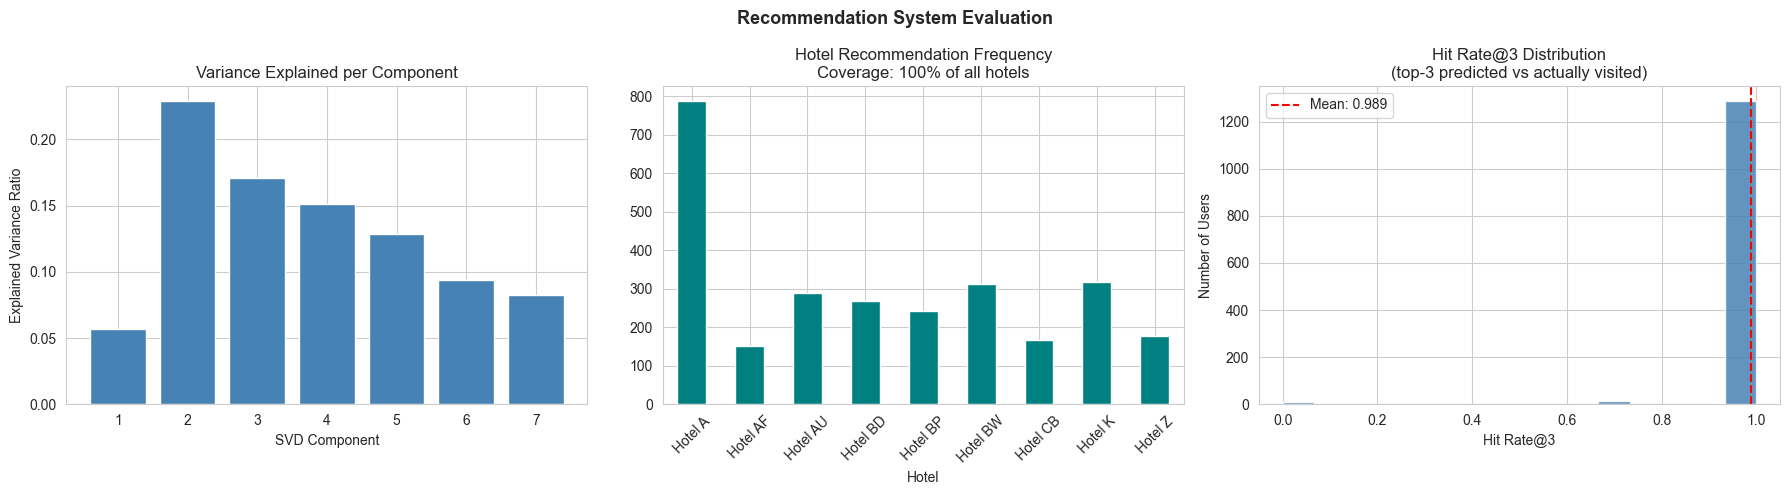

Saved: nb3_evaluation.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Recommendation System Evaluation', fontsize=13, fontweight='bold')

# 1. Explained variance per component
axes[0].bar(range(1, int(BEST_N)+1), SVD_FINAL.explained_variance_ratio_,
            color='steelblue', edgecolor='white')
axes[0].set_title('Variance Explained per Component')
axes[0].set_xlabel('SVD Component')
axes[0].set_ylabel('Explained Variance Ratio')

# 2. Recommendation frequency per hotel (coverage)
rec_counts = pd.Series(all_recs).value_counts().reindex(INTERACTION_MATRIX.columns, fill_value=0)
rec_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title(f'Hotel Recommendation Frequency\nCoverage: {coverage*100:.0f}% of all hotels')
axes[1].set_xlabel('Hotel')
axes[1].tick_params(axis='x', rotation=45)

# 3. Hit Rate distribution (replaces broken Precision@3)
axes[2].hist(hit_rates, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axvline(HIT_RATE_AT_3, color='red', linestyle='--',
                label=f'Mean: {HIT_RATE_AT_3:.3f}')
axes[2].set_title('Hit Rate@3 Distribution\n(top-3 predicted vs actually visited)')
axes[2].set_xlabel('Hit Rate@3')
axes[2].set_ylabel('Number of Users')
axes[2].legend()

plt.tight_layout()
plt.savefig('nb3_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb3_evaluation.png')


## 9. Save Model & Artefacts

In [14]:
joblib.dump(SVD_FINAL,           'svd_model.pkl')
joblib.dump(INTERACTION_MATRIX,  'interaction_matrix.pkl')
joblib.dump(RECON_DF,            'reconstructed_matrix.pkl')
joblib.dump(list(INTERACTION_MATRIX.columns), 'hotel_names.pkl')
print('Saved:')
print('  svd_model.pkl              — fitted TruncatedSVD model')
print('  interaction_matrix.pkl     — user × hotel interaction matrix')
print('  reconstructed_matrix.pkl   — predicted scores for all user-hotel pairs')
print('  hotel_names.pkl            — ordered list of hotel names')
print()
# Quick verification
loaded_svd = joblib.load('svd_model.pkl')
print('Loaded SVD n_components:', loaded_svd.n_components)
print('Explained variance:', loaded_svd.explained_variance_ratio_.sum().round(3))

Saved:
  svd_model.pkl              — fitted TruncatedSVD model
  interaction_matrix.pkl     — user × hotel interaction matrix
  reconstructed_matrix.pkl   — predicted scores for all user-hotel pairs
  hotel_names.pkl            — ordered list of hotel names

Loaded SVD n_components: 7
Explained variance: 0.912


## 8. Recommendation Function

This function is called by both the notebook tests and the Streamlit app. It loads all artefacts from disk — the same files just saved above — ensuring the function behaves identically in Colab, local, and deployed environments.

In [15]:
def recommend_hotels(user_code, top_n=3, verbose=True):
    """
    Recommend top-N unvisited hotels for a user using the SVD reconstructed matrix.

    Parameters
    ----------
    user_code : int   — userCode from hotels dataset
    top_n     : int   — number of hotels to return
    verbose   : bool  — print explanation

    Returns
    -------
    list of dicts: [{'hotel': str, 'predicted_score': float}]
    """
    matrix  = joblib.load('interaction_matrix.pkl')
    recon   = joblib.load('reconstructed_matrix.pkl')

    if user_code not in matrix.index:
        # Cold start: return globally most popular hotels
        popular = matrix.sum(axis=0).sort_values(ascending=False).head(top_n)
        if verbose:
            print(f'User {user_code} not found — returning most popular hotels (cold start)')
        return [{'hotel': h, 'predicted_score': round(float(s), 2), 'note': 'cold start'}
                for h, s in popular.items()]

    visited   = set(matrix.columns[matrix.loc[user_code] > 0])
    scores    = recon.loc[user_code]
    unvisited = scores.drop(list(visited), errors='ignore')

    if len(unvisited) == 0:
        recs = scores.sort_values(ascending=False).head(top_n)
        note = 'all hotels visited — ranked by preference score'
    else:
        recs = unvisited.sort_values(ascending=False).head(top_n)
        note = f'visited {len(visited)} hotels'

    if verbose:
        print(f'User {user_code} ({note}):')
        for hotel, score in recs.items():
            print(f'  → {hotel}: score={score:.2f}')

    return [{'hotel': h, 'predicted_score': round(float(s), 2)} for h, s in recs.items()]


# ── Test on 3 sample users ──
print('=== Recommendation Tests ===')
partial_users = INTERACTION_MATRIX.index[(INTERACTION_MATRIX > 0).sum(axis=1) < 9][:3]
for u in partial_users:
    print()
    recommend_hotels(u, top_n=3, verbose=True)


=== Recommendation Tests ===

User 1 (visited 2 hotels):
  → Hotel CB: score=0.08
  → Hotel Z: score=0.07
  → Hotel BD: score=0.06

User 5 (visited 7 hotels):
  → Hotel BP: score=0.01
  → Hotel AU: score=0.00

User 6 (visited 8 hotels):
  → Hotel Z: score=0.02


## 10. MLflow Run Summary

In [16]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
cols = ['tags.mlflow.runName','params.n_components','metrics.explained_variance',
        'metrics.reconstruction_rmse','metrics.coverage','metrics.avg_precision_at_3']
avail = [c for c in cols if c in runs.columns]
display(runs[avail].rename(columns=lambda c: c.replace('tags.','').replace('metrics.','').replace('params.','')))
print('\nTo launch MLflow UI in Colab:')
print('  !pip install pyngrok -q')
print('  from pyngrok import ngrok')
print('  import subprocess; subprocess.Popen(["mlflow","ui","--port","5000"])')
print('  print(ngrok.connect(5000))')

,mlflow.runName,n_components,explained_variance,reconstruction_rmse,coverage
0,svd_n7_components,7,0.912,0.058049,1.0



To launch MLflow UI in Colab:
  !pip install pyngrok -q
  from pyngrok import ngrok
  import subprocess; subprocess.Popen(["mlflow","ui","--port","5000"])
  print(ngrok.connect(5000))
